In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("../data/processed/monthly_category_demand.csv")
df['Month'] = pd.to_datetime(df['Month'])

df.head()


,Month,Category,Quantity
0,2012-01-01,Furniture,246
1,2012-01-01,Office Supplies,997
2,2012-01-01,Technology,220
3,2012-02-01,Furniture,278
4,2012-02-01,Office Supplies,800


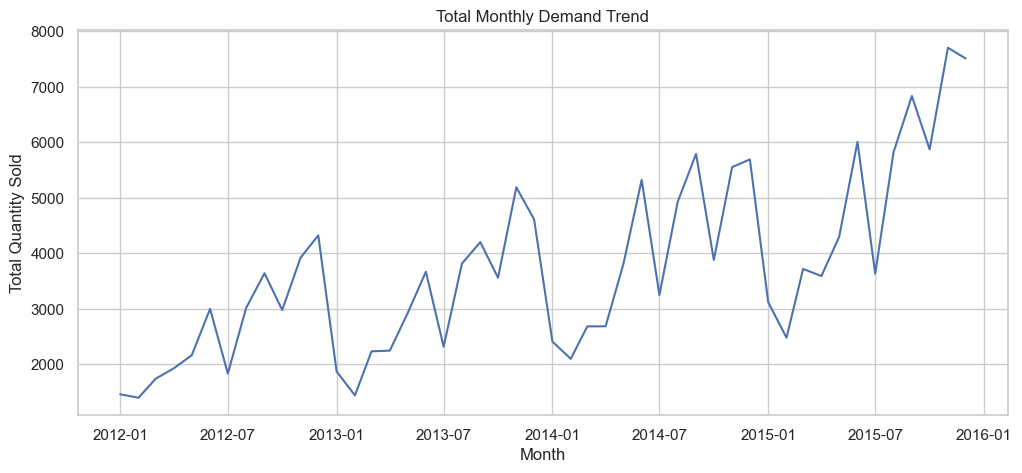

In [3]:
total_monthly = (
    df.groupby('Month')['Quantity']
      .sum()
      .reset_index()
)

plt.figure(figsize=(12,5))
plt.plot(total_monthly['Month'], total_monthly['Quantity'])
plt.title("Total Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Total Quantity Sold")
plt.show()


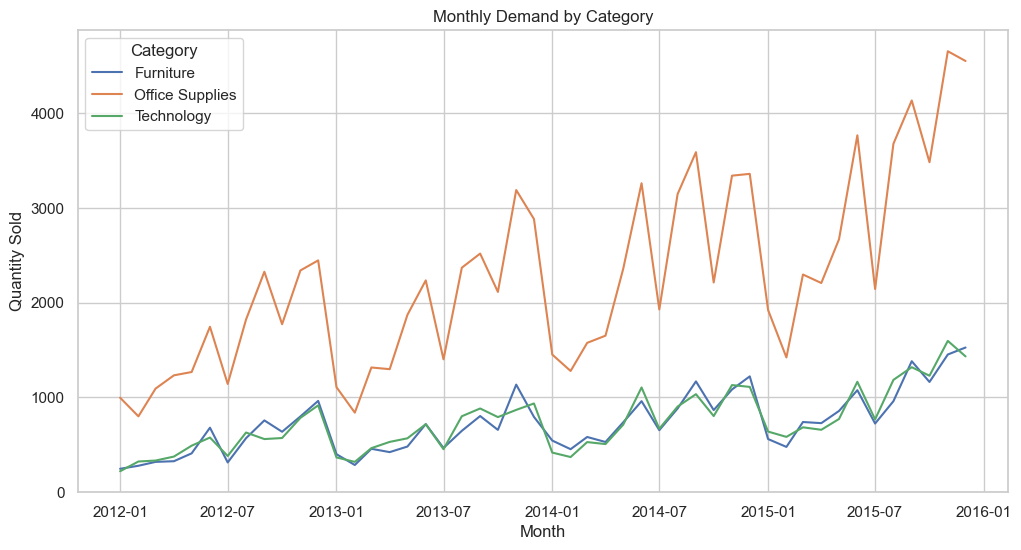

In [4]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Month', y='Quantity', hue='Category')
plt.title("Monthly Demand by Category")
plt.xlabel("Month")
plt.ylabel("Quantity Sold")
plt.legend(title="Category")
plt.show()


In [5]:
df['Month_Num'] = df['Month'].dt.month

seasonality = (
    df.groupby(['Month_Num', 'Category'])['Quantity']
      .mean()
      .reset_index()
)


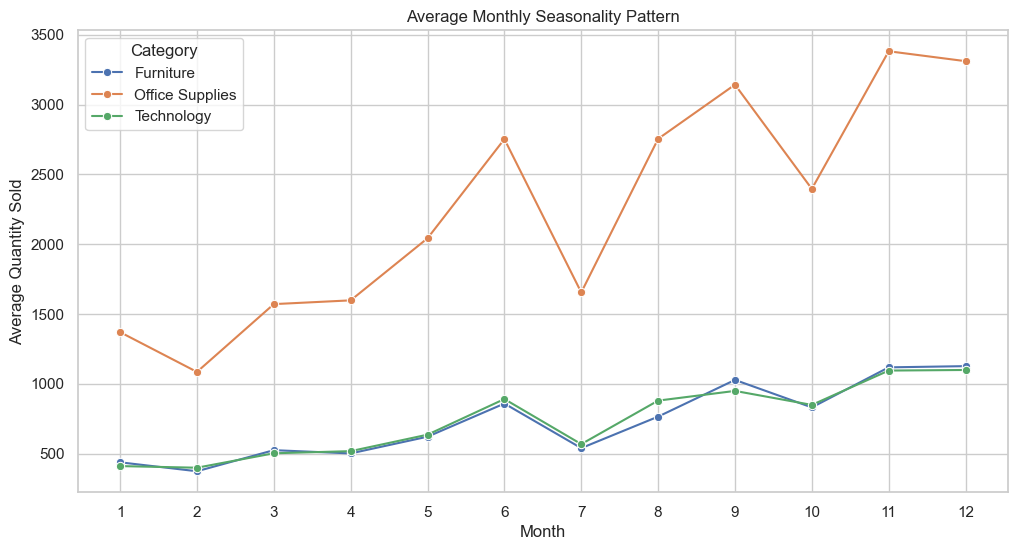

In [6]:
plt.figure(figsize=(12,6))
sns.lineplot(data=seasonality, x='Month_Num', y='Quantity', hue='Category', marker="o")
plt.title("Average Monthly Seasonality Pattern")
plt.xlabel("Month")
plt.ylabel("Average Quantity Sold")
plt.xticks(range(1,13))
plt.show()


In [7]:
volatility = (
    df.groupby('Category')['Quantity']
      .std()
      .reset_index()
      .sort_values(by='Quantity', ascending=False)
)

volatility


,Category,Quantity
1,Office Supplies,993.007142
0,Furniture,320.360291
2,Technology,319.480052


KEY EDA Insights:
Office Supplies has the highest consistent demand

Technology shows sharp spikes → higher safety stock needed

Strong seasonality in Q4 across all categories

Demand trend justifies time-series forecasting models